# Table 7 AGN Power Law Versus Redshift

This notebook reads `table_7.csv` from the `grahspj` repository root and plots the AGN continuum power-law slope, `alpha_lambda`, as a function of redshift for every AGN in the table.

## Setup

Run this notebook from `grahspj/notebooks` or from the repository root. The helper below finds the checkout root automatically.

In [ ]:
from pathlib import Path
import csv
import math
import os


def find_grahspj_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "src" / "grahspj").is_dir() and (path / "table_7.csv").is_file():
            return path
        nested = path / "grahspj"
        if (nested / "src" / "grahspj").is_dir() and (nested / "table_7.csv").is_file():
            return nested
    raise RuntimeError("Could not find the grahspj repository root with table_7.csv")


ROOT = find_grahspj_root()
TABLE7_PATH = ROOT / "table_7.csv"
OUTPUT_DIR = ROOT / "notebook_outputs" / "15_table7_agn_power_law_redshift"
MPLCONFIG_DIR = OUTPUT_DIR / "mplconfig"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))

print(f"Repository root: {ROOT}")
print(f"Reading: {TABLE7_PATH}")

Repository root: /home/nicho/GRAHSP/grahspj
Reading: /home/nicho/GRAHSP/grahspj/table_7.csv


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def as_float(value):
    if value is None or value == "":
        return np.nan
    try:
        return float(value)
    except ValueError:
        return np.nan


with TABLE7_PATH.open(newline="") as handle:
    rows = list(csv.DictReader(handle))

sdss_name = np.array([row["SDSS Name"] for row in rows])
redshift = np.array([as_float(row["z"]) for row in rows])
redshift_err = np.array([as_float(row["z_err"]) for row in rows])
alpha_lambda = np.array([as_float(row["alpha_lambda"]) for row in rows])
alpha_lambda_err = np.array([as_float(row["alpha_lambda_err"]) for row in rows])
m_2500 = np.array([as_float(row["m_2500"]) for row in rows])

valid = np.isfinite(redshift) & np.isfinite(alpha_lambda)

print(f"Loaded {len(rows):,} AGNs from Table 7")
print(f"Valid redshift and alpha_lambda values: {valid.sum():,}")
print(f"Redshift range: {np.nanmin(redshift):.3f} to {np.nanmax(redshift):.3f}")
print(f"alpha_lambda range: {np.nanmin(alpha_lambda):.3f} to {np.nanmax(alpha_lambda):.3f}")

Loaded 6,007 AGNs from Table 7
Valid redshift and alpha_lambda values: 6,007
Redshift range: 0.200 to 3.648
alpha_lambda range: -4.631 to 1.043


## Plot AGN Power-Law Slope Versus Redshift

The AGN power law in this table is represented by `alpha_lambda`. Points are colored by the 2500 Angstrom apparent magnitude, and the black line shows the median `alpha_lambda` in redshift bins.

Saved figure to /home/nicho/GRAHSP/grahspj/notebook_outputs/15_table7_agn_power_law_redshift/table7_alpha_lambda_vs_redshift.png


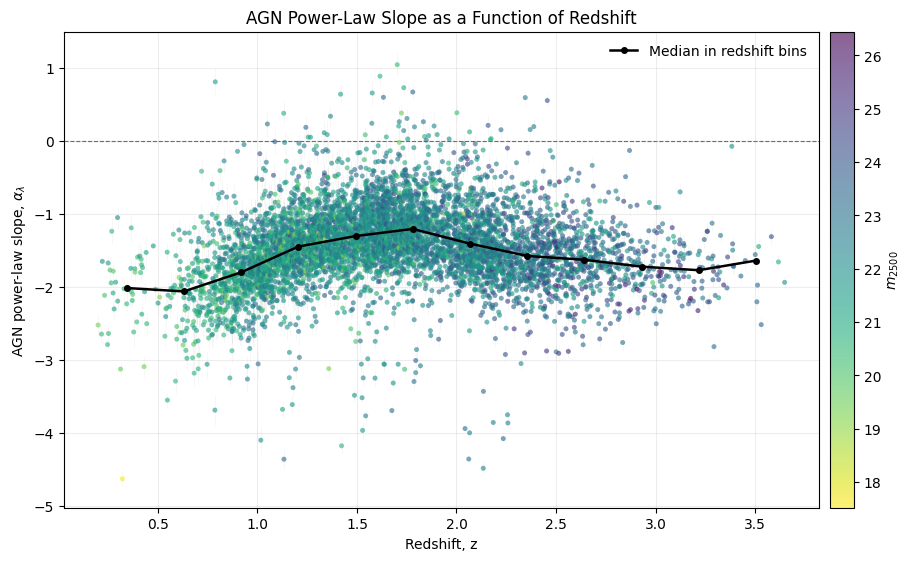

In [ ]:
plot_data = {
    "name": sdss_name[valid],
    "z": redshift[valid],
    "z_err": redshift_err[valid],
    "alpha_lambda": alpha_lambda[valid],
    "alpha_lambda_err": alpha_lambda_err[valid],
    "m_2500": m_2500[valid],
}

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)

err_mask = np.isfinite(plot_data["alpha_lambda_err"]) & (plot_data["alpha_lambda_err"] > 0)
xerr = np.where(np.isfinite(plot_data["z_err"]) & (plot_data["z_err"] > 0), plot_data["z_err"], 0.0)
ax.errorbar(
    plot_data["z"][err_mask],
    plot_data["alpha_lambda"][err_mask],
    xerr=xerr[err_mask],
    yerr=plot_data["alpha_lambda_err"][err_mask],
    fmt="none",
    ecolor="0.78",
    elinewidth=0.5,
    alpha=0.18,
    zorder=1,
)

scatter = ax.scatter(
    plot_data["z"],
    plot_data["alpha_lambda"],
    c=plot_data["m_2500"],
    s=13,
    cmap="viridis_r",
    alpha=0.62,
    linewidths=0,
    zorder=2,
)

bins = np.linspace(np.nanmin(plot_data["z"]), np.nanmax(plot_data["z"]), 13)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_medians = []
bin_counts = []
for left, right in zip(bins[:-1], bins[1:]):
    in_bin = (plot_data["z"] >= left) & (plot_data["z"] < right)
    bin_counts.append(in_bin.sum())
    bin_medians.append(np.nanmedian(plot_data["alpha_lambda"][in_bin]) if in_bin.any() else np.nan)

bin_medians = np.array(bin_medians)
bin_counts = np.array(bin_counts)
median_mask = np.isfinite(bin_medians) & (bin_counts > 0)
ax.plot(
    bin_centers[median_mask],
    bin_medians[median_mask],
    color="black",
    marker="o",
    markersize=4,
    linewidth=1.8,
    label="Median in redshift bins",
    zorder=3,
)

ax.axhline(0, color="0.35", linewidth=0.8, linestyle="--", zorder=0)
ax.set_xlabel("Redshift, z")
ax.set_ylabel(r"AGN power-law slope, $\alpha_\lambda$")
ax.set_title("AGN Power-Law Slope as a Function of Redshift")
ax.grid(alpha=0.22)
ax.legend(frameon=False, loc="best")

cbar = fig.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label(r"$m_{2500}$")

figure_path = OUTPUT_DIR / "table7_alpha_lambda_vs_redshift.png"
fig.savefig(figure_path, dpi=220)
print(f"Saved figure to {figure_path}")
plt.show()

## Optional: Inspect The Most Extreme Slopes

In [ ]:
order = np.argsort(plot_data["alpha_lambda"])
extreme_indices = np.concatenate([order[:5], order[-5:]])

print("SDSS Name             z       alpha_lambda  alpha_lambda_err")
print("----------------------------------------------------------")
for idx in extreme_indices:
    print(
        f"{plot_data['name'][idx]:<20} "
        f"{plot_data['z'][idx]:6.3f} "
        f"{plot_data['alpha_lambda'][idx]:13.3f} "
        f"{plot_data['alpha_lambda_err'][idx]:16.3f}"
    )

SDSS Name             z       alpha_lambda  alpha_lambda_err
----------------------------------------------------------
010151.08+002028.8    0.322        -4.631            0.101
024550.79-004328.2    2.135        -4.488            0.097
214340.08-010338.1    1.133        -4.363            0.140
222753.43+000003.7    2.062        -4.361            0.043
222235.71+003251.1    1.423        -4.180            0.107
015221.41+011419.7    1.780         0.669            0.111
015034.53-000200.7    1.735         0.728            0.106
020912.02+004719.0    0.788         0.808            0.184
020248.74+001046.4    1.616         0.885            0.133
002015.58-001412.3    1.703         1.043            0.156


## Independent Slope Check

A real independent check of `alpha_lambda` requires continuum flux density at two or more rest-frame wavelengths for the same AGN. Table 7 gives the fitted slope and a 2500 Angstrom normalization, but it does not include the original spectra or multiple continuum windows. The local `photometry_from_table7.csv` file also contains only one `2500A` point per source, so it cannot independently refit the slope.

In [ ]:
photometry_path = ROOT / "photometry_from_table7.csv"

if photometry_path.is_file():
    with photometry_path.open(newline="") as handle:
        photometry_rows = list(csv.DictReader(handle))

    wavelengths_by_source = {}
    for row in photometry_rows:
        source_id = row["source_id"]
        filter_name = row["filter_name"]
        wavelengths_by_source.setdefault(source_id, set()).add(filter_name)

    n_sources = len(wavelengths_by_source)
    n_with_two_or_more = sum(len(filters) >= 2 for filters in wavelengths_by_source.values())
    unique_filters = sorted({row["filter_name"] for row in photometry_rows})

    print(f"Photometry rows: {len(photometry_rows):,}")
    print(f"Sources with photometry: {n_sources:,}")
    print(f"Available filters/wavelength points: {unique_filters}")
    print(f"Sources with at least two points for an independent slope fit: {n_with_two_or_more:,}")
else:
    print(f"No local photometry file found at {photometry_path}")

Photometry rows: 6,007
Sources with photometry: 6,007
Available filters/wavelength points: ['2500A']
Sources with at least two points for an independent slope fit: 0


If we obtain continuum fluxes at two rest-frame wavelengths, the power-law slope can be calculated as:

`alpha_lambda = log(f_lambda_2 / f_lambda_1) / log(lambda_2 / lambda_1)`

for a wavelength-space power law `f_lambda ∝ lambda^alpha_lambda`.

In [ ]:
def alpha_lambda_from_two_points(lambda_1, flux_lambda_1, lambda_2, flux_lambda_2):
    lambda_1 = np.asarray(lambda_1, dtype=float)
    flux_lambda_1 = np.asarray(flux_lambda_1, dtype=float)
    lambda_2 = np.asarray(lambda_2, dtype=float)
    flux_lambda_2 = np.asarray(flux_lambda_2, dtype=float)
    return np.log(flux_lambda_2 / flux_lambda_1) / np.log(lambda_2 / lambda_1)


# Example of the formula using synthetic points generated from the CSV slope.
# This only verifies the algebra; it is not an independent test of Table 7.
check_indices = np.linspace(0, len(plot_data["alpha_lambda"]) - 1, 5, dtype=int)
lambda_1 = 2500.0
lambda_2 = 3000.0
flux_1 = np.ones_like(check_indices, dtype=float)
flux_2 = flux_1 * (lambda_2 / lambda_1) ** plot_data["alpha_lambda"][check_indices]
alpha_recovered = alpha_lambda_from_two_points(lambda_1, flux_1, lambda_2, flux_2)

print("SDSS Name             alpha_csv  alpha_recovered  delta")
print("-------------------------------------------------------")
for idx, recovered in zip(check_indices, alpha_recovered):
    alpha_csv = plot_data["alpha_lambda"][idx]
    print(
        f"{plot_data['name'][idx]:<20} "
        f"{alpha_csv:9.3f} "
        f"{recovered:15.3f} "
        f"{recovered - alpha_csv:8.2e}"
    )

SDSS Name             alpha_csv  alpha_recovered  delta
-------------------------------------------------------
012254.62+010106.6      -2.525          -2.525 0.00e+00
222110.75-001159.8      -1.159          -1.159 2.22e-16
013533.85+004807.4      -0.214          -0.214 -8.33e-17
025819.32-000806.3      -1.653          -1.653 -2.22e-16
234033.70-005636.9      -1.940          -1.940 0.00e+00


## SED-Fit Slope Test Against Table 7

This section fits a small sample of Table 7 AGNs with the same broad-band SED machinery used in notebook 10, extracts the fitted AGN disk continuum, measures a local wavelength-space slope, and compares it to the Table 7 `alpha_lambda` values. This is a consistency check of the photometric SED model, not a direct reproduction of the original spectral fit that produced Table 7.

In [ ]:
# Set this to True to run the SED fitting comparison. It may query external catalogs
# through Bandwagon/CDS XMatch and can take several minutes even for a small sample.
RUN_SED_SLOPE_TEST = False

SED_TEST_SAMPLE_SIZE = 3
SED_TEST_RANDOM_SEED = 20260529
SED_FIT_STEPS = 800
SED_FIT_LEARNING_RATE = 5e-3
SED_MIN_BANDS_TO_FIT = 5

# Rest-frame wavelength range used to measure the local continuum slope from disk_rest_sed.
# The fitted slope is for L_lambda or f_lambda versus wavelength, matching alpha_lambda convention.
SLOPE_WAVE_RANGE_A = (1700.0, 3000.0)

SED_OUTPUT_DIR = OUTPUT_DIR / "sed_slope_test"
SED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
if RUN_SED_SLOPE_TEST:
    import re
    import sys
    import astropy.units as u
    from astropy.coordinates import SkyCoord
    from astropy.table import Table

    grahspj_src = ROOT / "src"
    bandwagon_src = ROOT.parent / "bandwagon" / "src"
    for path in (grahspj_src, bandwagon_src):
        if path.is_dir() and str(path) not in sys.path:
            sys.path.insert(0, str(path))

    from bandwagon import matches_to_photometry, xmatch_catalogs
    from grahspj.config import (
        AGNConfig,
        FilterSet,
        FitConfig,
        GalaxyConfig,
        InferenceConfig,
        LikelihoodConfig,
        Observation,
        PhotometryData,
    )
    from grahspj.core import GRAHSPJ

    FILTER_SPECLITE_NAME = {
        "FUV_galex": "galex-fuv",
        "NUV_galex": "galex-nuv",
        "u_sdss": "sdss2010-u",
        "g_sdss": "sdss2010-g",
        "r_sdss": "sdss2010-r",
        "i_sdss": "sdss2010-i",
        "z_sdss": "sdss2010-z",
        "W1": "wise2010-W1",
        "W2": "wise2010-W2",
        "W3": "wise2010-W3",
        "W4": "wise2010-W4",
    }
    FILTER_ORDER = {name: i for i, name in enumerate(FILTER_SPECLITE_NAME)}
else:
    print("SED slope test skipped. Set RUN_SED_SLOPE_TEST = True to run it.")

SED slope test skipped. Set RUN_SED_SLOPE_TEST = True to run it.


In [ ]:
if RUN_SED_SLOPE_TEST:
    def safe_float(value, default=np.nan):
        try:
            text = str(value).strip()
            if text == "" or text.lower() in {"nan", "none", "--"}:
                return default
            return float(text)
        except Exception:
            return default


    table7_by_name = {row["SDSS Name"]: row for row in rows}
    finite_indices = np.flatnonzero(valid)
    rng = np.random.default_rng(SED_TEST_RANDOM_SEED)
    selected_indices = rng.choice(
        finite_indices,
        size=min(SED_TEST_SAMPLE_SIZE, finite_indices.size),
        replace=False,
    )

    selected_rows = [rows[int(idx)] for idx in selected_indices]
    selected_source_ids = np.array([row["SDSS Name"] for row in selected_rows], dtype=str)
    selected_ra = np.array([safe_float(row["RA"]) for row in selected_rows], dtype=float)
    selected_dec = np.array([safe_float(row["Dec"]) for row in selected_rows], dtype=float)
    selected_z = np.array([safe_float(row["z"]) for row in selected_rows], dtype=float)

    selected_coords = SkyCoord(ra=selected_ra * u.deg, dec=selected_dec * u.deg, frame="icrs")

    print("Selected sources for SED slope test:")
    for source_id, z_value, alpha_value in zip(
        selected_source_ids,
        selected_z,
        alpha_lambda[selected_indices],
    ):
        print(f"  {source_id:20s} z={z_value:.3f} alpha_lambda={alpha_value:.3f}")

In [ ]:
if RUN_SED_SLOPE_TEST:
    matches = xmatch_catalogs(selected_coords, source_id=selected_source_ids)
    for catalog_name, match_table in matches.items():
        print(f"{catalog_name:10s}: {len(match_table):6d} matched rows")

    sed_photometry = matches_to_photometry(matches, max_mag_err=1.0)
    print(f"Long-form photometry rows: {len(sed_photometry):,}")

    if len(sed_photometry):
        filters, counts = np.unique(np.asarray(sed_photometry["filter_name"], dtype=str), return_counts=True)
        print("Rows by filter:")
        for name, count in zip(filters, counts):
            print(f"  {name:10s} {count:5d}")

In [ ]:
if RUN_SED_SLOPE_TEST:
    dsps_ssp_fn = ROOT / "tempdata.h5"
    assert dsps_ssp_fn.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn}"

    sed_source_ids = np.asarray(sed_photometry["source_id"], dtype=str) if len(sed_photometry) else np.asarray([], dtype=str)
    unique_ids, band_counts = np.unique(sed_source_ids, return_counts=True)
    fit_source_ids = [sid for sid, count in zip(unique_ids, band_counts) if count >= SED_MIN_BANDS_TO_FIT]
    print(f"Sources with at least {SED_MIN_BANDS_TO_FIT} usable bands: {len(fit_source_ids):,}")

    def sed_rows_for_source(source_id):
        mask = np.asarray(sed_photometry["source_id"], dtype=str) == str(source_id)
        source_rows = sed_photometry[mask]
        order = np.argsort([FILTER_ORDER.get(str(name), 999) for name in source_rows["filter_name"]])
        return source_rows[order]


    def build_sed_fit_config(source_id, source_rows):
        table_row = table7_by_name[str(source_id)]
        filter_names = [str(name) for name in source_rows["filter_name"]]
        fluxes = np.asarray(source_rows["flux_mjy"], dtype=float)
        errors = np.asarray(source_rows["flux_err_mjy"], dtype=float)
        errors = np.maximum(errors, 0.03 * fluxes)
        psf = [safe_float(value) for value in source_rows["psf_fwhm_arcsec"]] if "psf_fwhm_arcsec" in source_rows.colnames else [np.nan] * len(source_rows)

        return FitConfig(
            observation=Observation(
                object_id=str(source_id),
                redshift=safe_float(table_row["z"]),
                fit_redshift=False,
                ra=safe_float(table_row["RA"]),
                dec=safe_float(table_row["Dec"]),
            ),
            photometry=PhotometryData(
                filter_names=filter_names,
                fluxes=fluxes.tolist(),
                errors=errors.tolist(),
                is_upper_limit=[False] * len(source_rows),
                psf_fwhm_arcsec=psf,
            ),
            filters=FilterSet(
                speclite_names={str(row["filter_name"]): str(row["speclite_name"]) for row in source_rows},
                use_grahsp_database=False,
            ),
            galaxy=GalaxyConfig(dsps_ssp_fn=str(dsps_ssp_fn), n_wave=768),
            agn=AGNConfig(agn_type=1),
            likelihood=LikelihoodConfig(
                systematics_width=0.08,
                variability_uncertainty=True,
                use_host_capture_model=True,
            ),
            inference=InferenceConfig(
                map_steps=SED_FIT_STEPS,
                learning_rate=SED_FIT_LEARNING_RATE,
                seed=SED_TEST_RANDOM_SEED,
            ),
            prior_config={
                "log_stellar_mass": {"loc": 10.5, "scale": 1.25},
                "fracAGN_5100": {"loc": 0.75, "scale": 0.2},
                "ebv_gal": {"scale": 0.2},
                "ebv_agn": {"scale": 0.2},
            },
        )

In [ ]:
if RUN_SED_SLOPE_TEST:
    def local_loglog_slope(wave, luminosity, wave_range):
        wave = np.asarray(wave, dtype=float)
        luminosity = np.asarray(luminosity, dtype=float)
        mask = (
            np.isfinite(wave)
            & np.isfinite(luminosity)
            & (luminosity > 0)
            & (wave >= wave_range[0])
            & (wave <= wave_range[1])
        )
        if mask.sum() < 3:
            return np.nan
        slope, intercept = np.polyfit(np.log(wave[mask]), np.log(luminosity[mask]), deg=1)
        return float(slope)


    sed_slope_rows = []
    for source_id in fit_source_ids:
        source_rows = sed_rows_for_source(source_id)
        cfg = build_sed_fit_config(source_id, source_rows)
        fitter = GRAHSPJ(cfg)
        print(f"Fitting {source_id} with {len(source_rows)} bands...")
        try:
            map_result = fitter.fit_map(
                steps=SED_FIT_STEPS,
                learning_rate=SED_FIT_LEARNING_RATE,
                progress_bar=False,
            )
            pred = fitter.predict()
            rest_wave = np.nanmedian(np.asarray(pred["rest_wave"], dtype=float), axis=0)
            disk_rest_sed = np.nanmedian(np.asarray(pred["disk_rest_sed"], dtype=float), axis=0)
            alpha_sed = local_loglog_slope(rest_wave, disk_rest_sed, SLOPE_WAVE_RANGE_A)
            alpha_csv = safe_float(table7_by_name[str(source_id)]["alpha_lambda"])
            alpha_csv_err = safe_float(table7_by_name[str(source_id)]["alpha_lambda_err"])
            final_loss = float(np.asarray(map_result.get("losses", [np.nan]), dtype=float)[-1])
            sed_slope_rows.append(
                {
                    "source_id": str(source_id),
                    "redshift": cfg.observation.redshift,
                    "n_bands": len(source_rows),
                    "alpha_lambda_csv": alpha_csv,
                    "alpha_lambda_err_csv": alpha_csv_err,
                    "alpha_lambda_sed_fit": alpha_sed,
                    "delta_alpha": alpha_sed - alpha_csv,
                    "uv_slope_map": safe_float(fitter.map_result["median"].get("uv_slope", np.nan)),
                    "pl_slope_map": safe_float(fitter.map_result["median"].get("pl_slope", np.nan)),
                    "final_loss": final_loss,
                }
            )
        except Exception as exc:
            print(f"Failed {source_id}: {exc}")

    sed_slope_results = Table(rows=sed_slope_rows)
    sed_slope_results_path = SED_OUTPUT_DIR / "table7_sed_slope_comparison.ecsv"
    if len(sed_slope_results):
        sed_slope_results.write(sed_slope_results_path, overwrite=True)
        print(f"Saved comparison table to {sed_slope_results_path}")
    sed_slope_results

In [ ]:
if RUN_SED_SLOPE_TEST and len(sed_slope_results):
    fig, ax = plt.subplots(figsize=(5.6, 5.2), constrained_layout=True)
    x = np.asarray(sed_slope_results["alpha_lambda_csv"], dtype=float)
    y = np.asarray(sed_slope_results["alpha_lambda_sed_fit"], dtype=float)
    if "alpha_lambda_err_csv" in sed_slope_results.colnames:
        xerr = np.asarray(sed_slope_results["alpha_lambda_err_csv"], dtype=float)
    else:
        xerr = np.array([safe_float(table7_by_name[str(source_id)]["alpha_lambda_err"]) for source_id in sed_slope_results["source_id"]], dtype=float)
    xerr = np.where(np.isfinite(xerr) & (xerr > 0), xerr, 0.0)
    finite = np.isfinite(x) & np.isfinite(y)
    ax.errorbar(
        x[finite],
        y[finite],
        xerr=xerr[finite],
        fmt="none",
        ecolor="0.72",
        elinewidth=0.8,
        alpha=0.65,
        zorder=1,
    )
    ax.scatter(x[finite], y[finite], s=45, color="#20639B", alpha=0.8, zorder=2)
    if finite.any():
        lim_min = np.nanmin([x[finite].min(), y[finite].min()]) - 0.2
        lim_max = np.nanmax([x[finite].max(), y[finite].max()]) + 0.2
        ax.plot([lim_min, lim_max], [lim_min, lim_max], color="0.25", linestyle="--", linewidth=1)
        ax.set_xlim(lim_min, lim_max)
        ax.set_ylim(lim_min, lim_max)
    ax.set_xlabel(r"Table 7 $\alpha_\lambda$")
    ax.set_ylabel(r"SED-fit local disk slope")
    ax.set_title("Table 7 vs. Broad-Band SED Continuum Slope")
    ax.grid(alpha=0.22)

    sed_slope_figure_path = SED_OUTPUT_DIR / "table7_vs_sed_fit_alpha_lambda.png"
    fig.savefig(sed_slope_figure_path, dpi=220)
    print(f"Saved figure to {sed_slope_figure_path}")
    plt.show()

## Full Table 7 SED-Fit Slope Run

The cells below run the same SED-fit slope measurement for Table 7 objects in batches, save partial results, and plot recovered SED-fit slope versus redshift. This is intended as a long-running production cell: it can query external catalogs and fit thousands of objects, so it is disabled by default.

In [ ]:
# Change this to True when you are ready to run the full Table 7 SED-slope pass.
RUN_FULL_TABLE7_SED_SLOPE_FITS = True

# Leave as None for all Table 7 AGNs. Set a small integer for a smoke test.
FULL_SED_MAX_OBJECTS = None
FULL_SED_BATCH_SIZE = 5
FULL_SED_FIT_STEPS = 800
FULL_SED_FIT_LEARNING_RATE = 5e-3
FULL_SED_MIN_BANDS_TO_FIT = 5
FULL_SED_MAX_MAG_ERR = 1.0
FULL_SED_RANDOM_SEED = 20260529
FULL_SED_SLOPE_WAVE_RANGE_A = (1700.0, 3000.0)

FULL_SED_OUTPUT_DIR = OUTPUT_DIR / "full_table7_sed_slope_fits"
FULL_SED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FULL_SED_RESULTS_PATH = FULL_SED_OUTPUT_DIR / "table7_full_sed_slope_results.ecsv"
FULL_SED_FAILURES_PATH = FULL_SED_OUTPUT_DIR / "table7_full_sed_slope_failures.ecsv"

print(f"Results path: {FULL_SED_RESULTS_PATH}")
print(f"Failures path: {FULL_SED_FAILURES_PATH}")

Results path: /home/nicho/GRAHSP/grahspj/notebook_outputs/15_table7_agn_power_law_redshift/full_table7_sed_slope_fits/table7_full_sed_slope_results.ecsv
Failures path: /home/nicho/GRAHSP/grahspj/notebook_outputs/15_table7_agn_power_law_redshift/full_table7_sed_slope_fits/table7_full_sed_slope_failures.ecsv


In [ ]:
if RUN_FULL_TABLE7_SED_SLOPE_FITS:
    import gc
    import sys
    import astropy.units as u
    from astropy.coordinates import SkyCoord
    try:
        import jax
    except Exception:
        jax = None
    from astropy.table import Table

    grahspj_src = ROOT / "src"
    bandwagon_src = ROOT.parent / "bandwagon" / "src"
    for path in (grahspj_src, bandwagon_src):
        if path.is_dir() and str(path) not in sys.path:
            sys.path.insert(0, str(path))

    from bandwagon import matches_to_photometry, xmatch_catalogs
    from grahspj.config import (
        AGNConfig,
        FilterSet,
        FitConfig,
        GalaxyConfig,
        InferenceConfig,
        LikelihoodConfig,
        Observation,
        PhotometryData,
    )
    from grahspj.core import GRAHSPJ

    FILTER_SPECLITE_NAME_FULL = {
        "FUV_galex": "galex-fuv",
        "NUV_galex": "galex-nuv",
        "u_sdss": "sdss2010-u",
        "g_sdss": "sdss2010-g",
        "r_sdss": "sdss2010-r",
        "i_sdss": "sdss2010-i",
        "z_sdss": "sdss2010-z",
        "W1": "wise2010-W1",
        "W2": "wise2010-W2",
        "W3": "wise2010-W3",
        "W4": "wise2010-W4",
    }
    FILTER_ORDER_FULL = {name: i for i, name in enumerate(FILTER_SPECLITE_NAME_FULL)}
else:
    print("Full Table 7 SED-fit slope run skipped. Set RUN_FULL_TABLE7_SED_SLOPE_FITS = True to run it.")

Could not import regions, which is required for some of the functionalities of this module.


/home/nicho/miniconda3/envs/astro2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/nicho/miniconda3/envs/astro2/lib/python3.11/site-packages/dustmaps/config.py:74: ConfigWarning: Configuration file not found:

    /home/nicho/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.
  warn(('Configuration file not found:\n\n'


In [ ]:
if RUN_FULL_TABLE7_SED_SLOPE_FITS:
    def safe_float_full(value, default=np.nan):
        try:
            text = str(value).strip()
            if text == "" or text.lower() in {"nan", "none", "--"}:
                return default
            return float(text)
        except Exception:
            return default


    def read_ecsv_rows(path):
        if not path.exists():
            return []
        return [dict(row) for row in Table.read(path, format="ascii.ecsv")]


    def write_ecsv_rows(rows_to_write, path):
        if rows_to_write:
            tmp_path = path.with_suffix(path.suffix + ".tmp")
            Table(rows=rows_to_write).write(tmp_path, format="ascii.ecsv", overwrite=True)
            tmp_path.replace(path)


    def save_full_sed_progress():
        write_ecsv_rows(full_success_rows, FULL_SED_RESULTS_PATH)
        write_ecsv_rows(full_failure_rows, FULL_SED_FAILURES_PATH)


    def cleanup_full_sed_memory():
        gc.collect()
        if jax is not None:
            try:
                jax.clear_caches()
            except Exception:
                pass


    def local_loglog_slope_full(wave, luminosity, wave_range):
        wave = np.asarray(wave, dtype=float)
        luminosity = np.asarray(luminosity, dtype=float)
        mask = (
            np.isfinite(wave)
            & np.isfinite(luminosity)
            & (luminosity > 0)
            & (wave >= wave_range[0])
            & (wave <= wave_range[1])
        )
        if mask.sum() < 3:
            return np.nan
        slope, intercept = np.polyfit(np.log(wave[mask]), np.log(luminosity[mask]), deg=1)
        return float(slope)


    def plot_full_table7_progress(success_rows, output_path=None, show=True):
        table_z = redshift[valid]
        table_z_err = redshift_err[valid]
        table_alpha = alpha_lambda[valid]
        table_alpha_err = alpha_lambda_err[valid]
        table_m2500 = m_2500[valid]

        fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)

        err_mask = np.isfinite(table_alpha_err) & (table_alpha_err > 0)
        xerr = np.where(np.isfinite(table_z_err) & (table_z_err > 0), table_z_err, 0.0)
        ax.errorbar(
            table_z[err_mask],
            table_alpha[err_mask],
            xerr=xerr[err_mask],
            yerr=table_alpha_err[err_mask],
            fmt="none",
            ecolor="0.82",
            elinewidth=0.5,
            alpha=0.14,
            zorder=1,
        )

        scatter = ax.scatter(
            table_z,
            table_alpha,
            c=table_m2500,
            s=13,
            cmap="viridis_r",
            alpha=0.52,
            linewidths=0,
            label="Table 7 alpha_lambda",
            zorder=2,
        )

        bins = np.linspace(np.nanmin(table_z), np.nanmax(table_z), 13)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bin_medians = []
        bin_counts = []
        for left, right in zip(bins[:-1], bins[1:]):
            in_bin = (table_z >= left) & (table_z < right)
            bin_counts.append(in_bin.sum())
            bin_medians.append(np.nanmedian(table_alpha[in_bin]) if in_bin.any() else np.nan)

        bin_medians = np.asarray(bin_medians)
        bin_counts = np.asarray(bin_counts)
        median_mask = np.isfinite(bin_medians) & (bin_counts > 0)
        ax.plot(
            bin_centers[median_mask],
            bin_medians[median_mask],
            color="black",
            marker="o",
            markersize=4,
            linewidth=1.8,
            label="Table 7 median in redshift bins",
            zorder=3,
        )

        if success_rows:
            done = Table(rows=success_rows)
            done_z = np.asarray(done["redshift"], dtype=float)
            done_alpha = np.asarray(done["alpha_lambda_sed_fit"], dtype=float)
            if "redshift_err" in done.colnames:
                done_z_err = np.asarray(done["redshift_err"], dtype=float)
            else:
                done_z_err = np.array([safe_float_full(table7_full_by_name[str(source_id)]["z_err"]) for source_id in done["source_id"]], dtype=float)
            done_z_err = np.where(np.isfinite(done_z_err) & (done_z_err > 0), done_z_err, 0.0)
            done_finite = np.isfinite(done_z) & np.isfinite(done_alpha)
            if done_finite.any():
                ax.errorbar(
                    done_z[done_finite],
                    done_alpha[done_finite],
                    xerr=done_z_err[done_finite],
                    fmt="none",
                    ecolor="#D95F02",
                    elinewidth=0.7,
                    alpha=0.45,
                    zorder=3,
                )
                ax.scatter(
                    done_z[done_finite],
                    done_alpha[done_finite],
                    s=28,
                    color="#D95F02",
                    edgecolors="white",
                    linewidths=0.35,
                    alpha=0.9,
                    label=f"Completed SED fits ({done_finite.sum():,})",
                    zorder=4,
                )

        ax.axhline(0, color="0.35", linewidth=0.8, linestyle="--", zorder=0)
        ax.set_xlabel("Redshift, z")
        ax.set_ylabel(r"AGN power-law slope, $\alpha_\lambda$")
        ax.set_title("Table 7 Power-Law Slope With Completed SED Fits")
        ax.grid(alpha=0.22)
        ax.legend(frameon=False, loc="best")

        cbar = fig.colorbar(scatter, ax=ax, pad=0.015)
        cbar.set_label(r"$m_{2500}$")

        if output_path is not None:
            fig.savefig(output_path, dpi=220)
            print(f"Saved current Table 7 progress plot to {output_path}")
        if show:
            plt.show()
        else:
            plt.close(fig)
        return fig


    table7_full_by_name = {row["SDSS Name"]: row for row in rows}
    dsps_ssp_fn_full = ROOT / "tempdata.h5"
    assert dsps_ssp_fn_full.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn_full}"


In [ ]:
if RUN_FULL_TABLE7_SED_SLOPE_FITS:
    def full_sed_rows_for_source(photometry_table, source_id):
        mask = np.asarray(photometry_table["source_id"], dtype=str) == str(source_id)
        source_rows = photometry_table[mask]
        order = np.argsort([FILTER_ORDER_FULL.get(str(name), 999) for name in source_rows["filter_name"]])
        return source_rows[order]


    def build_full_sed_fit_config(source_id, source_rows):
        table_row = table7_full_by_name[str(source_id)]
        filter_names = [str(name) for name in source_rows["filter_name"]]
        fluxes = np.asarray(source_rows["flux_mjy"], dtype=float)
        errors = np.asarray(source_rows["flux_err_mjy"], dtype=float)
        errors = np.maximum(errors, 0.03 * fluxes)
        psf = [safe_float_full(value) for value in source_rows["psf_fwhm_arcsec"]] if "psf_fwhm_arcsec" in source_rows.colnames else [np.nan] * len(source_rows)

        return FitConfig(
            observation=Observation(
                object_id=str(source_id),
                redshift=safe_float_full(table_row["z"]),
                fit_redshift=False,
                ra=safe_float_full(table_row["RA"]),
                dec=safe_float_full(table_row["Dec"]),
            ),
            photometry=PhotometryData(
                filter_names=filter_names,
                fluxes=fluxes.tolist(),
                errors=errors.tolist(),
                is_upper_limit=[False] * len(source_rows),
                psf_fwhm_arcsec=psf,
            ),
            filters=FilterSet(
                speclite_names={str(row["filter_name"]): str(row["speclite_name"]) for row in source_rows},
                use_grahsp_database=False,
            ),
            galaxy=GalaxyConfig(dsps_ssp_fn=str(dsps_ssp_fn_full), n_wave=768),
            agn=AGNConfig(agn_type=1),
            likelihood=LikelihoodConfig(
                systematics_width=0.08,
                variability_uncertainty=True,
                use_host_capture_model=True,
            ),
            inference=InferenceConfig(
                map_steps=FULL_SED_FIT_STEPS,
                learning_rate=FULL_SED_FIT_LEARNING_RATE,
                seed=FULL_SED_RANDOM_SEED,
            ),
            prior_config={
                "log_stellar_mass": {"loc": 10.5, "scale": 1.25},
                "fracAGN_5100": {"loc": 0.75, "scale": 0.2},
                "ebv_gal": {"scale": 0.2},
                "ebv_agn": {"scale": 0.2},
            },
        )

In [ ]:
if RUN_FULL_TABLE7_SED_SLOPE_FITS:
    full_success_rows = read_ecsv_rows(FULL_SED_RESULTS_PATH)
    full_failure_rows = read_ecsv_rows(FULL_SED_FAILURES_PATH)
    completed_ids = {str(row["source_id"]) for row in full_success_rows}
    failed_ids = {str(row["source_id"]) for row in full_failure_rows}
    attempted_ids = completed_ids | failed_ids

    target_indices = np.flatnonzero(valid)
    if FULL_SED_MAX_OBJECTS is not None:
        target_indices = target_indices[: int(FULL_SED_MAX_OBJECTS)]

    target_rows = [rows[int(idx)] for idx in target_indices]
    pending_rows = [row for row in target_rows if str(row["SDSS Name"]) not in attempted_ids]

    print(f"Target Table 7 objects: {len(target_rows):,}")
    print(f"Already successful: {len(completed_ids):,}")
    print(f"Already failed/skipped: {len(failed_ids):,}")
    print(f"Pending: {len(pending_rows):,}")

    prefit_progress_path = FULL_SED_OUTPUT_DIR / "table7_progress_before_continuing_fits.png"
    plot_full_table7_progress(full_success_rows, output_path=prefit_progress_path, show=True)

Target Table 7 objects: 6,007
Already successful: 275
Already failed/skipped: 0
Pending: 5,732


In [ ]:
if RUN_FULL_TABLE7_SED_SLOPE_FITS:
    for batch_start in range(0, len(pending_rows), FULL_SED_BATCH_SIZE):
        batch_matches = None
        batch_photometry = None
        batch_rows = pending_rows[batch_start : batch_start + FULL_SED_BATCH_SIZE]
        batch_ids = np.array([str(row["SDSS Name"]) for row in batch_rows], dtype=str)
        batch_ra = np.array([safe_float_full(row["RA"]) for row in batch_rows], dtype=float)
        batch_dec = np.array([safe_float_full(row["Dec"]) for row in batch_rows], dtype=float)
        finite_coords = np.isfinite(batch_ra) & np.isfinite(batch_dec)

        if not finite_coords.any():
            for source_id in batch_ids:
                full_failure_rows.append({"source_id": source_id, "reason": "missing RA/Dec"})
            save_full_sed_progress()
            del batch_rows, batch_ids, batch_ra, batch_dec, finite_coords
            cleanup_full_sed_memory()
            continue

        query_ids = batch_ids[finite_coords]
        query_coords = SkyCoord(ra=batch_ra[finite_coords] * u.deg, dec=batch_dec[finite_coords] * u.deg, frame="icrs")
        print(f"Batch {batch_start // FULL_SED_BATCH_SIZE + 1}: querying and fitting {len(query_ids)} objects")

        try:
            batch_matches = xmatch_catalogs(query_coords, source_id=query_ids)
            batch_photometry = matches_to_photometry(batch_matches, max_mag_err=FULL_SED_MAX_MAG_ERR)
        except Exception as exc:
            for source_id in query_ids:
                full_failure_rows.append({"source_id": str(source_id), "reason": f"xmatch failed: {exc}"})
            save_full_sed_progress()
            del batch_matches, batch_photometry, batch_rows, batch_ids, batch_ra, batch_dec, finite_coords, query_ids, query_coords
            cleanup_full_sed_memory()
            continue

        for source_id in query_ids:
            source_rows = None
            cfg = None
            fitter = None
            map_result = None
            pred = None
            rest_wave = None
            disk_rest_sed = None
            table_row = None
            losses = None
            try:
                source_rows = full_sed_rows_for_source(batch_photometry, source_id) if len(batch_photometry) else batch_photometry
                if len(source_rows) < FULL_SED_MIN_BANDS_TO_FIT:
                    full_failure_rows.append({
                        "source_id": str(source_id),
                        "reason": f"only {len(source_rows)} usable bands",
                    })
                else:
                    cfg = build_full_sed_fit_config(source_id, source_rows)
                    fitter = GRAHSPJ(cfg)
                    try:
                        map_result = fitter.fit_map(
                            steps=FULL_SED_FIT_STEPS,
                            learning_rate=FULL_SED_FIT_LEARNING_RATE,
                            progress_bar=False,
                        )
                        pred = fitter.predict()
                        rest_wave = np.nanmedian(np.asarray(pred["rest_wave"], dtype=float), axis=0)
                        disk_rest_sed = np.nanmedian(np.asarray(pred["disk_rest_sed"], dtype=float), axis=0)
                        recovered_slope = local_loglog_slope_full(rest_wave, disk_rest_sed, FULL_SED_SLOPE_WAVE_RANGE_A)
                        table_row = table7_full_by_name[str(source_id)]
                        losses = np.asarray(map_result.get("losses", [np.nan]), dtype=float)

                        full_success_rows.append({
                            "source_id": str(source_id),
                            "redshift": safe_float_full(table_row["z"]),
                            "redshift_err": safe_float_full(table_row["z_err"]),
                            "n_bands": len(source_rows),
                            "alpha_lambda_csv": safe_float_full(table_row["alpha_lambda"]),
                            "alpha_lambda_err_csv": safe_float_full(table_row["alpha_lambda_err"]),
                            "alpha_lambda_sed_fit": recovered_slope,
                            "delta_alpha": recovered_slope - safe_float_full(table_row["alpha_lambda"]),
                            "uv_slope_map": safe_float_full(fitter.map_result["median"].get("uv_slope", np.nan)),
                            "pl_slope_map": safe_float_full(fitter.map_result["median"].get("pl_slope", np.nan)),
                            "log_agn_amp_map": safe_float_full(fitter.map_result["median"].get("log_agn_amp", np.nan)),
                            "final_loss": float(losses[-1]) if losses.size else np.nan,
                        })
                    except Exception as exc:
                        full_failure_rows.append({"source_id": str(source_id), "reason": f"fit failed: {exc}"})

                save_full_sed_progress()
                print(
                    f"Saved progress after {source_id}: {len(full_success_rows):,} successes, "
                    f"{len(full_failure_rows):,} failures/skips"
                )
            finally:
                del source_rows, cfg, fitter, map_result, pred, rest_wave, disk_rest_sed, table_row, losses
                cleanup_full_sed_memory()

        del batch_matches, batch_photometry, batch_rows, batch_ids, batch_ra, batch_dec, finite_coords, query_ids, query_coords
        cleanup_full_sed_memory()


Batch 1: querying and fitting 5 objects
Saved progress after 221200.74-011354.9: 276 successes, 0 failures/skips
Saved progress after 010801.82+001212.5: 277 successes, 0 failures/skips
Saved progress after 005410.64+003533.7: 278 successes, 0 failures/skips
Saved progress after 221952.07+000054.1: 279 successes, 0 failures/skips
Saved progress after 215710.15+005815.6: 280 successes, 0 failures/skips
Batch 2: querying and fitting 5 objects
Saved progress after 023313.79-003155.6: 281 successes, 0 failures/skips
Saved progress after 213427.04+003437.6: 282 successes, 0 failures/skips
Saved progress after 234354.78-000109.3: 283 successes, 0 failures/skips
Saved progress after 033217.82+001033.9: 284 successes, 0 failures/skips
Saved progress after 004351.42+000956.8: 285 successes, 0 failures/skips
Batch 3: querying and fitting 5 objects
Saved progress after 204104.41-003040.9: 286 successes, 0 failures/skips
Saved progress after 014746.44+002929.0: 287 successes, 0 failures/skips
Save

KeyboardInterrupt: 

In [ ]:
try:
    from astropy.table import Table
except Exception:
    Table = None

if Table is not None and FULL_SED_RESULTS_PATH.exists():
    full_sed_results = Table.read(FULL_SED_RESULTS_PATH, format="ascii.ecsv")
    z_fit = np.asarray(full_sed_results["redshift"], dtype=float)
    recovered_slope = np.asarray(full_sed_results["alpha_lambda_sed_fit"], dtype=float)
    n_bands = np.asarray(full_sed_results["n_bands"], dtype=float)
    if "redshift_err" in full_sed_results.colnames:
        z_fit_err = np.asarray(full_sed_results["redshift_err"], dtype=float)
    else:
        z_fit_err = np.array([safe_float_full(table7_full_by_name[str(source_id)]["z_err"]) for source_id in full_sed_results["source_id"]], dtype=float)
    z_fit_err = np.where(np.isfinite(z_fit_err) & (z_fit_err > 0), z_fit_err, 0.0)
    finite = np.isfinite(z_fit) & np.isfinite(recovered_slope)

    fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
    ax.errorbar(
        z_fit[finite],
        recovered_slope[finite],
        xerr=z_fit_err[finite],
        fmt="none",
        ecolor="0.72",
        elinewidth=0.7,
        alpha=0.55,
        zorder=1,
    )
    scatter = ax.scatter(
        z_fit[finite],
        recovered_slope[finite],
        c=n_bands[finite],
        s=16,
        cmap="viridis",
        alpha=0.72,
        linewidths=0,
        zorder=2,
    )

    if finite.sum() >= 5:
        bins = np.linspace(np.nanmin(z_fit[finite]), np.nanmax(z_fit[finite]), 13)
        centers = 0.5 * (bins[:-1] + bins[1:])
        medians = []
        counts = []
        for left, right in zip(bins[:-1], bins[1:]):
            in_bin = (z_fit >= left) & (z_fit < right) & finite
            counts.append(in_bin.sum())
            medians.append(np.nanmedian(recovered_slope[in_bin]) if in_bin.any() else np.nan)
        medians = np.asarray(medians)
        counts = np.asarray(counts)
        good_bins = np.isfinite(medians) & (counts > 0)
        ax.plot(centers[good_bins], medians[good_bins], color="black", marker="o", linewidth=1.8, markersize=4, label="Median in redshift bins")
        ax.legend(frameon=False, loc="best")

    ax.set_xlabel("Redshift, z")
    ax.set_ylabel(r"Recovered SED-fit disk slope")
    ax.set_title("Recovered Broad-Band SED Continuum Slope Versus Redshift")
    ax.grid(alpha=0.22)
    cbar = fig.colorbar(scatter, ax=ax, pad=0.015)
    cbar.set_label("Number of fitted bands")

    full_sed_slope_vs_z_path = FULL_SED_OUTPUT_DIR / "table7_full_sed_slope_vs_redshift.png"
    fig.savefig(full_sed_slope_vs_z_path, dpi=220)
    print(f"Loaded {len(full_sed_results):,} successful fits")
    print(f"Saved figure to {full_sed_slope_vs_z_path}")
    plt.show()
else:
    print(f"No full-run results found yet at {FULL_SED_RESULTS_PATH}")

No full-run results found yet at /home/nicho/GRAHSP/grahspj/notebook_outputs/15_table7_agn_power_law_redshift/full_table7_sed_slope_fits/table7_full_sed_slope_results.ecsv
